In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from datetime import datetime
import os, time


from scipy import stats
from sklearn.linear_model import LinearRegression
from typing import Optional
from fastf1.core import Session
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import grangercausalitytests
!pip install fastf1
import fastf1 as ff1
from fastf1 import plotting


os.chdir('/Users/jackson/Documents/ECON570')

In [3]:
import fastf1
fastf1.Cache.enable_cache("F1/f1_cache") # use a cache file if running multiple times, this api takes forever to run otherwise


In [4]:
years = range(2014, 2024)  #parse the past 10 years

records = []

for year in years:
    session = ff1.get_session(year, "Bahrain Grand Prix", "R")
    session.load()

    for drv in session.drivers:
        d = session.get_driver(drv)
        records.append({
            "year": year,
            "team_f1": d["TeamName"],     # e.g. 'Mercedes', 'McLaren'
            "driver_code": d["Abbreviation"],  # 'HAM', 'NOR', etc.
            "driver_name": d["FullName"]
        })

driver_year_df = pd.DataFrame(records)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
logger      WARNING 	Failed to load session info data!
core        WARNING 	Cannot load laps, telemetry, weather, and message data because the relevant API is not supported for this session.
core           INFO 	Finished loading data for 22 drivers: ['44', '6', '11', '3', '27', '1', '19', '77', '14', '7', '26', '8', '4', '13', '10', '17', '22', '20', '21', '9', '25', '99']
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
logger      WARNING 	Failed to load session info data!
core        WARNING 	Cannot load laps, telemetry, weather, and message data because the relevant API is not supported for this session.
core           INFO 	Finished loa

In [5]:
#assign drivers to a df with lineups in each year
team_lineups = (
    driver_year_df
    .groupby(["team_f1", "year"])["driver_code"]
    .apply(lambda x: tuple(sorted(set(x))))
    .reset_index(name="drivers")
)

In [6]:
team_lineups = team_lineups.sort_values(["team_f1", "year"]) # set up for previous year comparison

team_lineups["drivers_prev"] = (
    team_lineups
    .groupby("team_f1")["drivers"]
    .shift(1)
)

team_lineups["driver_change"] = (
    (team_lineups["drivers"] != team_lineups["drivers_prev"])
    .astype(int)
)

In [7]:
name_map = {
    "Mercedes": "Mercedes",       # or 'Mercedes-Benz Grand Prix Ltd'
    "McLaren": "McLaren",
    "Ferrari": "Ferrari",
    "Red Bull Racing": "Red Bull",  # etc.
    # add others
}

team_lineups["team_clean_name"] = team_lineups["team_f1"].map(name_map)


In [8]:
profits_df = pd.read_csv("F1/f1_financial_data.csv")
profits_df.head()


profits_df = profits_df.rename(columns={
    "Team": "team_clean_name",
    "Year": "year",
    "Operating Profit (£m)": "profit"   #main profit metric
})

profits_df.head()
panel = team_lineups.merge(
    profits_df,
    on=["team_clean_name", "year"],
    how="inner"
)

# Profit change vs previous season within a team
panel = panel.sort_values(["team_clean_name", "year"])

panel["profit_prev"] = (
    panel
    .groupby("team_clean_name")["profit"]
    .shift(1)
)

panel["profit_change"] = panel["profit"] - panel["profit_prev"]

panel.head()



,team_f1,year,drivers,drivers_prev,driver_change,team_clean_name,Legal Entity,Country,Revenue (£m),profit,Net Income (£m),Prize Money (£m),Employees,Source,profit_prev,profit_change
0,Ferrari,2019,"(LEC, VET)","(RAI, VET)",1,Ferrari,Gestione Sportiva (Ferrari S.p.A.),Italy,380,13,10,180,950,Ferrari Annual Report,NaN,NaN
1,Ferrari,2020,"(LEC, VET)","(LEC, VET)",0,Ferrari,Gestione Sportiva (Ferrari S.p.A.),Italy,350,9,7,165,930,NaN,13.0,-4.0
2,Ferrari,2021,"(LEC, SAI)","(LEC, VET)",1,Ferrari,Gestione Sportiva (Ferrari S.p.A.),Italy,365,12,9,170,940,NaN,9.0,3.0
3,Ferrari,2022,"(LEC, SAI)","(LEC, SAI)",0,Ferrari,Gestione Sportiva (Ferrari S.p.A.),Italy,392,15,12,178,960,NaN,12.0,3.0
4,Ferrari,2023,"(LEC, SAI)","(LEC, SAI)",0,Ferrari,Gestione Sportiva (Ferrari S.p.A.),Italy,405,17,13,180,970,NaN,15.0,2.0


### Teams can change title sponsors, hence different team names and tax filings. Below I clean up all of the different names.

In [9]:


name_map = {
    # Sauber lineage
    "Sauber": "Alfa Romeo",
    "Alfa Romeo Racing": "Alfa Romeo",
    "Alfa Romeo": "Alfa Romeo",

    # Toro Rosso / AlphaTauri lineage
    "Toro Rosso": "AlphaTauri",
    "AlphaTauri": "AlphaTauri",

    # Renault / Lotus / Alpine lineage
    "Renault": "Alpine",
    "Lotus F1": "Alpine",
    "Alpine": "Alpine",

    # Force India / Racing Point / Aston Martin lineage
    "Force India": "Aston Martin",
    "Racing Point": "Aston Martin",
    "Aston Martin": "Aston Martin",

    # Red Bull lineage
    "Red Bull": "Red Bull Racing",
    "Red Bull Racing": "Red Bull Racing",

    # Marussia / Manor
    "Marussia": "Manor Marussia",
    "Manor Marussia": "Manor Marussia",

    # Stable names
    "Ferrari": "Ferrari",
    "McLaren": "McLaren",
    "Mercedes": "Mercedes",
    "Haas F1 Team": "Haas F1 Team",
    "Caterham": "Caterham",}

team_lineups["team_clean_name"] = (
    team_lineups["team_f1"].map(name_map).fillna(team_lineups["team_f1"])
)

team_lineups[["team_f1", "team_clean_name"]].drop_duplicates().sort_values("team_f1")



team_lineups["team_clean_name"] = team_lineups["team_f1"].map(name_map)



In [10]:
print(team_lineups.columns)
print(team_lineups[["team_f1", "team_clean_name"]].drop_duplicates().head(20)) # all team names and new names


Index(['team_f1', 'year', 'drivers', 'drivers_prev', 'driver_change',
       'team_clean_name'],
      dtype='object')
              team_f1  team_clean_name
0          Alfa Romeo       Alfa Romeo
2   Alfa Romeo Racing       Alfa Romeo
5          AlphaTauri       AlphaTauri
9              Alpine           Alpine
12       Aston Martin     Aston Martin
15           Caterham         Caterham
16            Ferrari          Ferrari
26        Force India     Aston Martin
31       Haas F1 Team     Haas F1 Team
39           Lotus F1           Alpine
41     Manor Marussia   Manor Marussia
43           Marussia   Manor Marussia
44            McLaren          McLaren
54           Mercedes         Mercedes
64       Racing Point     Aston Martin
66           Red Bull  Red Bull Racing
70    Red Bull Racing  Red Bull Racing
76            Renault           Alpine
81             Sauber       Alfa Romeo
86         Toro Rosso       AlphaTauri


### Now lets make a df with teams, and their profits in the past years. Drop teams like Marussia, and Non UK teams that didn't have tax filings publicly available.

In [11]:
    panel = team_lineups.merge(
    profits_df[["team_clean_name", "year", "profit", "Revenue (£m)", "Net Income (£m)"]],
    on=["team_clean_name", "year"],
    how="inner"
)


## This DF Shows driver lineups, and profits. Now we are going to use the drivers column to make a categorical variable, that determines wether a not there is a new driver on that team for each year. FYI, Profit is Net Income in millions of British Pounds.

In [12]:
panel[["team_clean_name", "year", "drivers", "profit"]]


,team_clean_name,year,drivers,profit
0,AlphaTauri,2020,"(GAS, KVY)",1
1,AlphaTauri,2021,"(GAS, TSU)",2
2,AlphaTauri,2022,"(GAS, TSU)",3
3,AlphaTauri,2023,"(DEV, TSU)",4
4,Alpine,2021,"(ALO, OCO)",1
5,Alpine,2022,"(ALO, OCO)",3
6,Alpine,2023,"(GAS, OCO)",4
7,Aston Martin,2021,"(STR, VET)",2
8,Aston Martin,2022,"(HUL, STR)",5
9,Aston Martin,2023,"(ALO, STR)",8


In [13]:
panel["driver_change"] = (panel["drivers"] != panel["drivers_prev"]).astype(int) # 1 if lineup changed vs previous year, 0 otherwise
panel

,team_f1,year,drivers,drivers_prev,driver_change,team_clean_name,profit,Revenue (£m),Net Income (£m)
0,AlphaTauri,2020,"(GAS, KVY)",NaN,1,AlphaTauri,1,152,1
1,AlphaTauri,2021,"(GAS, TSU)","(GAS, KVY)",1,AlphaTauri,2,160,2
2,AlphaTauri,2022,"(GAS, TSU)","(GAS, TSU)",0,AlphaTauri,3,165,3
3,AlphaTauri,2023,"(DEV, TSU)","(GAS, TSU)",1,AlphaTauri,4,170,4
4,Alpine,2021,"(ALO, OCO)",NaN,1,Alpine,1,175,1
5,Alpine,2022,"(ALO, OCO)","(ALO, OCO)",0,Alpine,3,180,2
6,Alpine,2023,"(GAS, OCO)","(ALO, OCO)",1,Alpine,4,190,3
7,Aston Martin,2021,"(STR, VET)",NaN,1,Aston Martin,2,165,2
8,Aston Martin,2022,"(HUL, STR)","(STR, VET)",1,Aston Martin,5,175,4
9,Aston Martin,2023,"(ALO, STR)","(HUL, STR)",1,Aston Martin,8,195,7


Now we run an OLS regression that shows the correlation between driver change and profits.

In [14]:

panel = panel.sort_values(["team_clean_name", "year"])


panel["drivers_prev"] = (# previous drivers within each team
    panel
    .groupby("team_clean_name")["drivers"]
    .shift(1)
)

panel["driver_change"] = (panel["drivers"] != panel["drivers_prev"]).astype(int) # 1 if lineup changed vs previous year, 0 otherwise


# previous year's profit and profit change
panel["profit_prev"] = (
    panel
    .groupby("team_clean_name")["profit"]
    .shift(1)
)

panel["profit_change"] = panel["profit"] - panel["profit_prev"]

# drop first year per team
reg_data = panel.dropna(subset=["profit_prev"]).copy()


reg_data[["team_clean_name", "year", "drivers", "drivers_prev",
          "driver_change", "profit_prev", "profit", "profit_change"]]


model_fe = smf.ols(
    "profit_change ~ driver_change + C(team_clean_name) + C(year)",
    data=reg_data
).fit()

print(model_fe.summary())


                            OLS Regression Results                            
Dep. Variable:          profit_change   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     2.527
Date:                Mon, 08 Dec 2025   Prob (F-statistic):             0.0445
Time:                        20:03:53   Log-Likelihood:                -57.228
No. Observations:                  28   AIC:                             136.5
Df Residuals:                      17   BIC:                             151.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

So this is Ok... But does a good team/good driver make the difference? What if we control for points, so if a good driver goes to a team with a bad car, we can control for that, solely their effect on the team.

In [15]:

fastf1.Cache.enable_cache("F1/f1_cache") 

years = sorted(set(panel["year"])) 

records = []

for year in years:
    schedule = fastf1.get_event_schedule(year, include_testing=False)

    for _, event in schedule.iterrows():
        gp_name = event["EventName"]   # 'Australian Grand Prix'
        session = fastf1.get_session(year, gp_name, "R")
        session.load()

        res = session.results

        for _, row in res.iterrows():
            records.append({
                "year": year,
                "team_f1": row["TeamName"],
                "points_race": row["Points"]
            })

team_points_raw = pd.DataFrame(records)

team_points = (
    team_points_raw
    .groupby(["team_f1", "year"], as_index=False)
    .agg(points=("points_race", "sum"))
)
team_points.head()


core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 77 completed the race distance 00:00.387000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['77', '44', '33', '5', '16', '20', '27', '7', '18', '26', '10',

,team_f1,year,points
0,Alfa Romeo,2022,53.0
1,Alfa Romeo,2023,16.0
2,Alfa Romeo Racing,2019,57.0
3,Alfa Romeo Racing,2020,8.0
4,Alfa Romeo Racing,2021,13.0


In [36]:
# name_map from earlier
team_points["team_clean_name"] = team_points["team_f1"].map(name_map)
team_points = team_points.dropna(subset=["team_clean_name"])


panel = panel.merge(
    team_points[["team_clean_name", "year", "points"]],
    on=["team_clean_name", "year"],
    how="left"
)
#Create lagged points + points_change
panel = panel.sort_values(["team_clean_name", "year"])

panel["points_prev"] = panel.groupby("team_clean_name")["points"].shift(1)
panel["points_change"] = panel["points"] - panel["points_prev"]

#build regression dataset
reg_data = panel.dropna(subset=["profit_prev", "points_prev"]).copy()



#ols control for points
model_pts = smf.ols(
    "profit_change ~ driver_change + points_change + C(team_clean_name) + C(year)",
    data=reg_data
).fit()

model_pts.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          profit_change   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     2.522
Date:                Mon, 08 Dec 2025   Prob (F-statistic):             0.0453
Time:                        20:52:09   Log-Likelihood:                -55.899
No. Observations:                  28   AIC:                             135.8
Df Residuals:                      16   BIC:                             151.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 0.0583      1.611      0.036      0.972      -3.356       3.473
C(team_clean_name)[T.Alpine]             -0.3454      1.668     -0.207      0.839      -3.882       3.191
C(team_clean_name)[T.Aston Martin]        1.4522      1.683      0.863      0.401      -2.116       5.020
C(team_clean_name)[T.Ferrari]            -0.9032      1.757     -0.514      0.614      -4.627       2.821
C(team_clean_name)[T.McLaren]             0.4140      1.701      0.243      0.811      -3.191       4.019
C(team_clean_name)[T.Mercedes]           -2.3927      1.771     -1.351      0.196      -6.147       1.362
C(team_clean_name)[T.Red Bull Racing]    -1.6291      1.743     -0.935      0.364      -5.324       2.065
C(year)[T.2021]                           4.9887      1.393      3.581      0.002       2.035       7.942
C(year)[T.2022]                           1.8568      1.283      1.447      0.167      -0.864       4.577
C(year)[T.2023]                           1.6783      1.283      1.308      0.209      -1.041       4.397
driver_change                            -0.4879      1.116     -0.437      0.668      -2.853       1.877
points_change                             0.0047      0.004      1.262      0.225      -0.003       0.012
==============================================================================
Omnibus:                        1.242   Durbin-Watson:                   2.356
Prob(Omnibus):                  0.538   Jarque-Bera (JB):                0.305
Skew:                           0.040   Prob(JB):                        0.859
Kurtosis:                       3.505   Cond. No.                     1.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# I estimated a fixed-effects OLS model of year-over-year profit changes including controls for performance (Constructor points change), team fixed effects, and year fixed effects. The results show no statistically significant relationship between driver changes and profitability (β ≈ −0.49, p = 0.67). After controlling for performance and structural team differences, driver switches do not explain profit movements. The main drivers of profit variation are macro-level year effects, especially the rebound in 2021.

/var/folders/p7/dtlz136x1b5bmnvrgrl428wh0000gn/T/ipykernel_79971/1742670698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reg_data, x="driver_change", y="profit_change", palette="pastel")


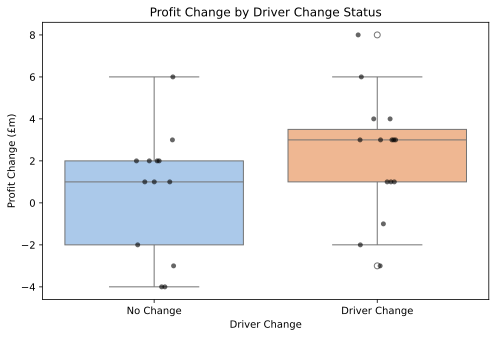

In [22]:
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(8,5))
sns.boxplot(data=reg_data, x="driver_change", y="profit_change", palette="pastel")
sns.stripplot(data=reg_data, x="driver_change", y="profit_change",
              color="black", alpha=0.6, jitter=True)
plt.xticks([0,1], ["No Change", "Driver Change"])
plt.xlabel("Driver Change")
plt.ylabel("Profit Change (£m)")
plt.title("Profit Change by Driver Change Status")
plt.show()


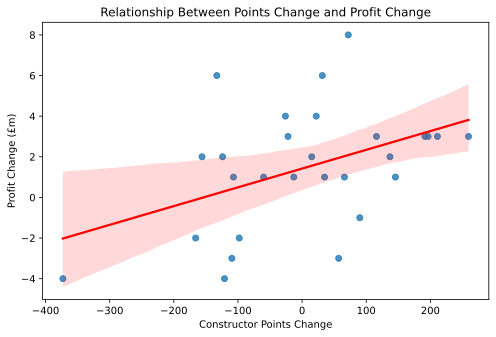

In [23]:
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(8,5))
sns.regplot(data=reg_data, x="points_change", y="profit_change",
            scatter_kws={"alpha":0.8}, line_kws={"color":"red"})
plt.xlabel("Constructor Points Change")
plt.ylabel("Profit Change (£m)")
plt.title("Relationship Between Points Change and Profit Change")
plt.show()


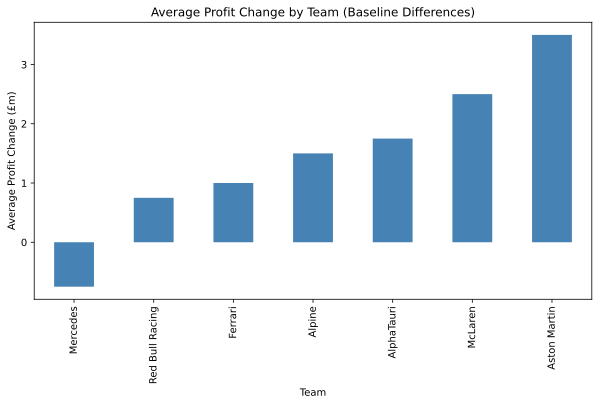

In [34]:
team_means = reg_data.groupby("team_clean_name")["profit_change"].mean()
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(10,5))
team_means.sort_values().plot(kind="bar", color="steelblue")
plt.ylabel("Average Profit Change (£m)")
plt.xlabel("Team")
plt.title("Average Profit Change by Team (Baseline Differences)")
plt.show()


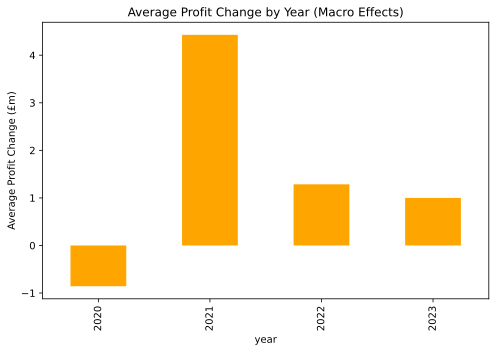

In [24]:
year_means = reg_data.groupby("year")["profit_change"].mean()
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(8,5))
year_means.plot(kind="bar", color="orange")
plt.ylabel("Average Profit Change (£m)")
plt.title("Average Profit Change by Year (Macro Effects)")
plt.show()


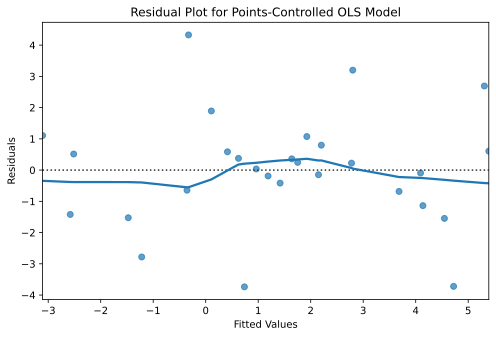

In [33]:
fig = plt.figure(figsize=(8,5))
sns.residplot(x=model_pts.fittedvalues, y=model_pts.resid, lowess=True,
              scatter_kws={"alpha":0.7})
%config InlineBackend.figure_format = 'svg'

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Points-Controlled OLS Model")
plt.show()


/var/folders/p7/dtlz136x1b5bmnvrgrl428wh0000gn/T/ipykernel_79971/1739014321.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x=clean_labels, y="coef", data=coef_df, join=False)


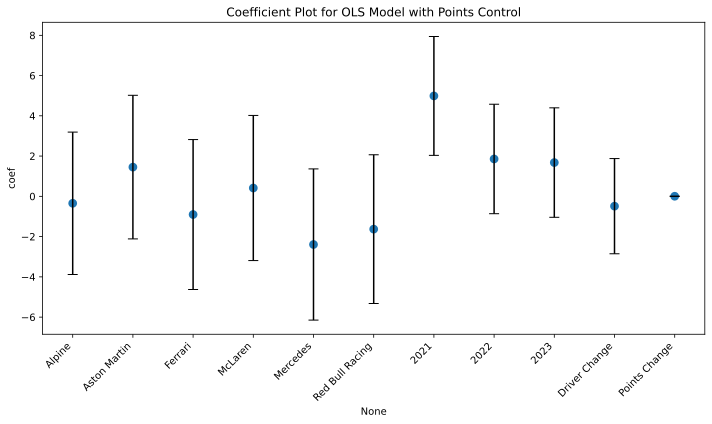

In [32]:
coef = model_pts.params
conf = model_pts.conf_int()

coef_df = pd.DataFrame({
    "coef": coef,
    "lower": conf[0],
    "upper": conf[1]
}).drop(["Intercept"])

# ----- CLEAN LABELS -----
clean_labels = (
    coef_df.index
    .str.replace("C\\(team_clean_name\\)\\[T\\.", "", regex=True)
    .str.replace("C\\(year\\)\\[T\\.", "", regex=True)
    .str.replace("\\]", "", regex=True)
    .str.replace("driver_change", "Driver Change")
    .str.replace("points_change", "Points Change")
)

# ----- PLOT -----
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(10,6))

sns.pointplot(x=clean_labels, y="coef", data=coef_df, join=False)

plt.errorbar(
    x=range(len(coef_df)),
    y=coef_df["coef"],
    yerr=[
        coef_df["coef"] - coef_df["lower"],
        coef_df["upper"] - coef_df["coef"]
    ],
    fmt="none",
    c="black",
    capsize=5
)

plt.xticks(rotation=45, ha="right")
plt.title("Coefficient Plot for OLS Model with Points Control")
plt.tight_layout()
plt.show()
